DATASET INFORMATION
Training samples : 8982
Testing samples  : 2246
Vocabulary size  : 12000
Maximum length   : 150
Number of classes: 46


TRAINING GRU
Epoch 1/8
113/113 ━━━━━━━━━━━━━━━━━━━━ 33s 255ms/step - accuracy: 0.3752 - loss: 2.4592 - val_accuracy: 0.4719 - val_loss: 1.9956
Epoch 2/8
113/113 ━━━━━━━━━━━━━━━━━━━━ 28s 252ms/step - accuracy: 0.5115 - loss: 1.8225 - val_accuracy: 0.5314 - val_loss: 1.7707
Epoch 3/8
113/113 ━━━━━━━━━━━━━━━━━━━━ 43s 267ms/step - accuracy: 0.5741 - loss: 1.6354 - val_accuracy: 0.5576 - val_loss: 1.7101
Epoch 4/8
113/113 ━━━━━━━━━━━━━━━━━━━━ 29s 253ms/step - accuracy: 0.6081 - loss: 1.5362 - val_accuracy: 0.5804 - val_loss: 1.6684
Epoch 5/8
113/113 ━━━━━━━━━━━━━━━━━━━━ 27s 238ms/step - accuracy: 0.6271 - loss: 1.4547 - val_accuracy: 0.6021 - val_loss: 1.6199
Epoch 6/8
113/113 ━━━━━━━━━━━━━━━━━━━━ 27s 238ms/step - accuracy: 0.6470 - loss: 1.3664 - val_accuracy: 0.6021 - val_loss: 1.5818
Epoch 7/8
113/113 ━━━━━━━━━━━━━━━━━━━━ 42s 247ms/step - accuracy: 0

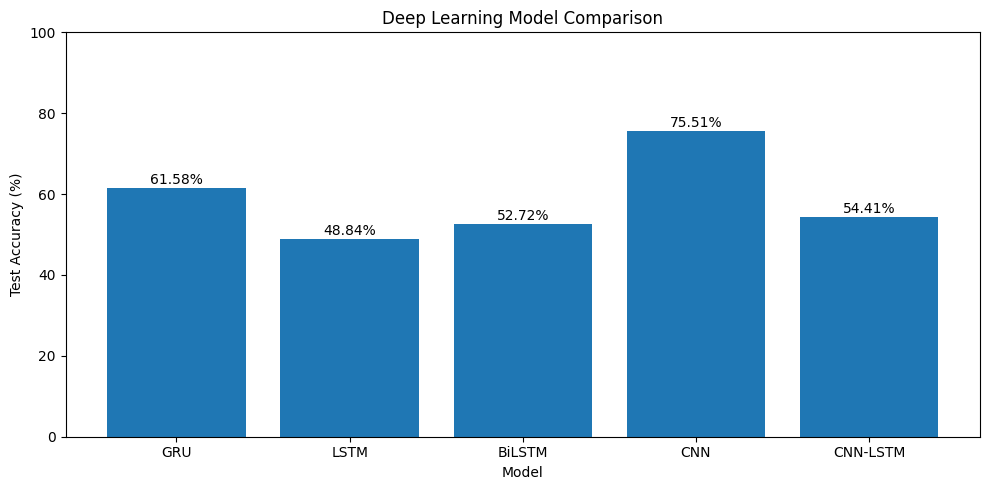



BEST MODEL
Model    : CNN
Accuracy : 75.51%


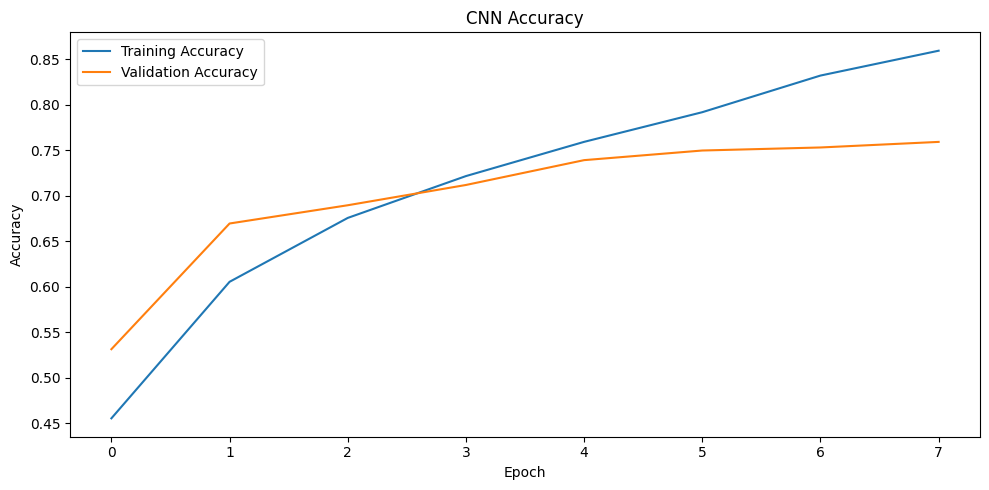

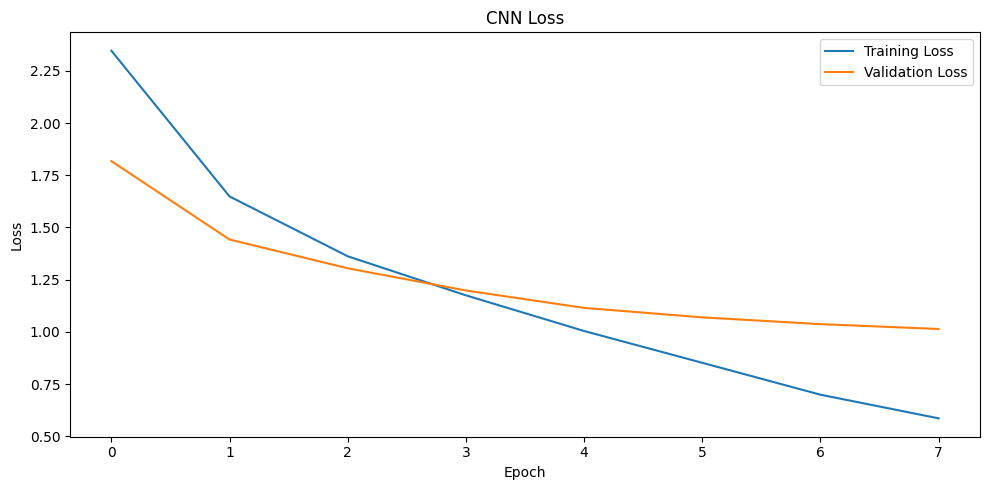



CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0     0.7000    0.5833    0.6364        12
           1     0.6241    0.8381    0.7154       105
           2     0.6250    0.5000    0.5556        20
           3     0.8855    0.9323    0.9083       813
           4     0.7730    0.8692    0.8183       474
           5     0.0000    0.0000    0.0000         5
           6     1.0000    0.7143    0.8333        14
           7     1.0000    0.3333    0.5000         3
           8     0.7586    0.5789    0.6567        38
           9     0.8696    0.8000    0.8333        25
          10     0.8889    0.8000    0.8421        30
          11     0.4677    0.6988    0.5604        83
          12     0.3333    0.0769    0.1250        13
          13     0.5926    0.4324    0.5000        37
          14     0.0000    0.0000    0.0000         2
          15     0.0000    0.0000    0.0000         9
          16     0.6696    0.7778    0.7196        99
   

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


<Figure size 1400x1200 with 0 Axes>

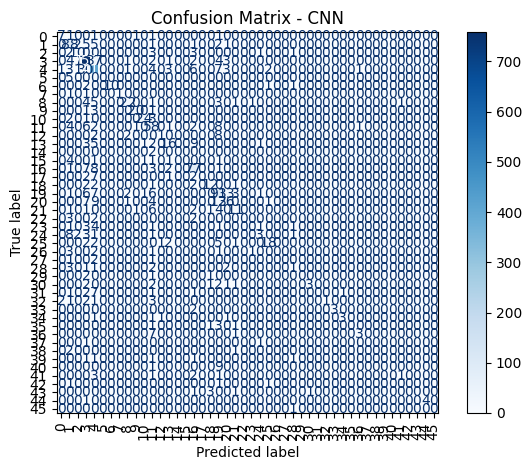



PROJECT SUMMARY
Models compared:
- GRU: 61.58%
- LSTM: 48.84%
- BiLSTM: 52.72%
- CNN: 75.51%
- CNN-LSTM: 54.41%

Best model: CNN
Best test accuracy: 75.51%


In [ ]:
# ============================================================
# NEWS TOPIC CLASSIFICATION USING DEEP LEARNING
# GRU | LSTM | BiLSTM | CNN | CNN-LSTM
# TensorFlow / Keras
# ============================================================

import numpy as np
import random
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# ============================================================
# 1. REPRODUCIBILITY
# ============================================================

SEED = 42

np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

# ============================================================
# 2. LOAD REUTERS DATASET
# ============================================================

vocab_size = 12000
maxlen = 150

(x_train, y_train), (x_test, y_test) = keras.datasets.reuters.load_data(
    num_words=vocab_size
)

x_train = keras.preprocessing.sequence.pad_sequences(
    x_train,
    maxlen=maxlen
)

x_test = keras.preprocessing.sequence.pad_sequences(
    x_test,
    maxlen=maxlen
)

num_classes = int(max(y_train) + 1)

print("========================================")
print("DATASET INFORMATION")
print("========================================")
print("Training samples :", len(x_train))
print("Testing samples  :", len(x_test))
print("Vocabulary size  :", vocab_size)
print("Maximum length   :", maxlen)
print("Number of classes:", num_classes)

# ============================================================
# 3. COMMON CALLBACK
# ============================================================

early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

# ============================================================
# 4. FUNCTION TO TRAIN AND EVALUATE
# ============================================================

results = {}
histories = {}
models = {}

def train_model(name, model):

    print("\n")
    print("=" * 60)
    print(f"TRAINING {name}")
    print("=" * 60)

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(
        x_train,
        y_train,
        epochs=8,
        batch_size=64,
        validation_split=0.2,
        callbacks=[early_stopping],
        verbose=1
    )

    test_loss, test_accuracy = model.evaluate(
        x_test,
        y_test,
        verbose=0
    )

    print(f"\n{name} Test Loss     : {test_loss:.4f}")
    print(f"{name} Test Accuracy : {test_accuracy:.4f}")

    results[name] = test_accuracy
    histories[name] = history
    models[name] = model

    return model


# ============================================================
# 5. GRU MODEL
# ============================================================

model_gru = keras.Sequential([
    layers.Embedding(vocab_size, 128),
    layers.GRU(64, dropout=0.3),
    layers.Dense(num_classes, activation="softmax")
])

train_model("GRU", model_gru)


# ============================================================
# 6. LSTM MODEL
# ============================================================

model_lstm = keras.Sequential([
    layers.Embedding(vocab_size, 128),
    layers.LSTM(64, dropout=0.3),
    layers.Dense(num_classes, activation="softmax")
])

train_model("LSTM", model_lstm)


# ============================================================
# 7. BIDIRECTIONAL LSTM
# ============================================================

model_bilstm = keras.Sequential([
    layers.Embedding(vocab_size, 128),
    layers.Bidirectional(
        layers.LSTM(64, dropout=0.3)
    ),
    layers.Dense(num_classes, activation="softmax")
])

train_model("BiLSTM", model_bilstm)


# ============================================================
# 8. CNN MODEL
# ============================================================

model_cnn = keras.Sequential([
    layers.Embedding(vocab_size, 128),
    layers.Conv1D(
        filters=64,
        kernel_size=5,
        activation="relu"
    ),
    layers.GlobalMaxPooling1D(),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation="softmax")
])

train_model("CNN", model_cnn)


# ============================================================
# 9. CNN + LSTM HYBRID
# ============================================================

model_cnn_lstm = keras.Sequential([
    layers.Embedding(vocab_size, 128),

    layers.Conv1D(
        filters=64,
        kernel_size=5,
        activation="relu"
    ),

    layers.MaxPooling1D(),

    layers.LSTM(64, dropout=0.3),

    layers.Dense(num_classes, activation="softmax")
])

train_model("CNN-LSTM", model_cnn_lstm)


# ============================================================
# 10. MODEL COMPARISON
# ============================================================

print("\n")
print("=" * 60)
print("FINAL MODEL COMPARISON")
print("=" * 60)

for name, accuracy in results.items():
    print(f"{name:12s} : {accuracy * 100:.2f}%")


# ============================================================
# 11. ACCURACY COMPARISON GRAPH
# ============================================================

plt.figure(figsize=(10, 5))

names = list(results.keys())
accuracies = [results[name] * 100 for name in names]

bars = plt.bar(names, accuracies)

plt.title("Deep Learning Model Comparison")
plt.xlabel("Model")
plt.ylabel("Test Accuracy (%)")
plt.ylim(0, 100)

for bar, accuracy in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{accuracy:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()


# ============================================================
# 12. FIND BEST MODEL
# ============================================================

best_model_name = max(
    results,
    key=results.get
)

best_accuracy = results[best_model_name]

print("\n")
print("=" * 60)
print("BEST MODEL")
print("=" * 60)

print("Model    :", best_model_name)
print(f"Accuracy : {best_accuracy * 100:.2f}%")


# ============================================================
# 13. TRAINING CURVES FOR BEST MODEL
# ============================================================

best_history = histories[best_model_name]

plt.figure(figsize=(10, 5))

plt.plot(
    best_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    best_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title(f"{best_model_name} Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 5))

plt.plot(
    best_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    best_history.history["val_loss"],
    label="Validation Loss"
)

plt.title(f"{best_model_name} Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()


# ============================================================
# 14. CLASSIFICATION REPORT
# ============================================================

best_model = models[best_model_name]

y_pred_probability = best_model.predict(
    x_test,
    verbose=0
)

y_pred = np.argmax(
    y_pred_probability,
    axis=1
)

print("\n")
print("=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred,
        digits=4
    )
)


# ============================================================
# 15. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(14, 12))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot(
    cmap="Blues",
    xticks_rotation="vertical"
)

plt.title(
    f"Confusion Matrix - {best_model_name}"
)

plt.tight_layout()
plt.show()


# ============================================================
# 16. FINAL SUMMARY
# ============================================================

print("\n")
print("=" * 60)
print("PROJECT SUMMARY")
print("=" * 60)

print("Models compared:")
for name in results:
    print(f"- {name}: {results[name] * 100:.2f}%")

print("\nBest model:", best_model_name)
print(f"Best test accuracy: {best_accuracy * 100:.2f}%")


In [ ]:
from sklearn.metrics import classification_report

report = classification_report(
    y_test,
    y_pred,
    digits=4
)

with open("classification_report.txt", "w") as f:
    f.write(report)

print("classification_report.txt created successfully")

classification_report.txt created successfully


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from google.colab import drive
drive.mount('/content/drive')